# Notebook 7: Capstone — Assisted Hinge Impedance Control

## From Passive to Assisted: Sharing the Load

In Notebook 6 we tracked a pendulum angle trajectory with the hinge unactuated (passive).
The two-level controller handled everything: it computed the desired cable tension from
the impedance error, converted that to a desired cable length, and used block position
control to achieve it. The hinge motor was idle (`ctrl[1] = 0`).

**Now we add a proportional hinge assist:** the hinge motor applies a torque equal to
a fraction of the impedance torque — the same signal the cable receives, but delivered
directly at the joint. This "shared load" means the cable needs to carry less of the
required torque, which reduces block travel and improves tracking accuracy.

**Same controller, same gains, same trajectory — only the environment changes.**

The pedagogical comparison:

| Scenario | Hinge motor | Cable job |
|----------|-------------|--------------------|
| Passive  | Off | All torque through cable |
| Assisted | Proportional assist | Share torque with hinge |

## Setup (Self-Contained)

In [1]:
import os
import dms
import dms.mujoco
import mujoco
import numpy as np
import matplotlib.pyplot as plt
import mediapy
%matplotlib inline

print(f"MuJoCo version: {mujoco.__version__}")

MuJoCo version: 3.6.0


In [2]:
# Self-contained: load model and extract indices (same as NB 06)
model_path = dms.get_asset_path('mujoco_models/tendon_block_hinge.xml')
model = mujoco.MjModel.from_xml_path(str(model_path))
data  = mujoco.MjData(model)

hinge_qpos_idx  = model.joint("hinge").qposadr[0]
hinge_vel_idx   = model.joint("hinge").dofadr[0]
block_slide_idx = model.joint("block_slide").qposadr[0]
block_vel_idx   = model.joint("block_slide").dofadr[0]
block_ctrl_idx  = model.actuator("block_motor").id
hinge_ctrl_idx  = model.actuator("hinge_motor").id

tendon_id       = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_TENDON, "cable")
L_natural       = model.tendon_lengthspring[tendon_id, 1]
CABLE_STIFFNESS = model.tendon_stiffness[tendon_id]

print(f"Model loaded: nq={model.nq}, nu={model.nu}, ntendon={model.ntendon}")
print(f"L_natural={L_natural:.4f} m, stiffness={CABLE_STIFFNESS:.1f} N/m")

Model loaded: nq=2, nu=2, ntendon=1
L_natural=2.0000 m, stiffness=200.0 N/m


## Controller (Identical to Notebook 06 — Same Gains, Same Structure)

In [3]:
# Same gains and controller as NB 06 -- only tau_hinge changes between scenarios
K        = 50.0    # Nm/rad
D        = 10.0    # Nm*s/rad
L_ROD    = 0.5     # m -- pendulum rod length

CORNER_X = 0.5
CORNER_Z = 1.5
PIVOT_X  = 0.0
PIVOT_Z  = 1.0
SEG1_AT_ZERO = 1.5

K_BLOCK  = 2000.0  # N/m
D_BLOCK  = 50.0    # N*s/m


def compute_r_eff(q):
    """Signed effective moment arm: Y-component of (r x f_hat)."""
    tip_x = PIVOT_X + L_ROD * np.cos(q)
    tip_z = PIVOT_Z - L_ROD * np.sin(q)
    r_x = tip_x - PIVOT_X
    r_z = tip_z - PIVOT_Z
    dx = CORNER_X - tip_x
    dz = CORNER_Z - tip_z
    d  = np.sqrt(dx**2 + dz**2)
    return r_z * (dx / d) - r_x * (dz / d)


def capstone_controller(model, data, q_des, dq_des, tau_hinge=0.0):
    """Two-level impedance controller (identical to NB 06).

    tau_hinge=0.0 -> passive scenario (NB 06 baseline)
    tau_hinge>0.0 -> assisted scenario (NB 07)
    """
    q  = data.qpos[hinge_qpos_idx].copy()
    dq = data.qvel[hinge_vel_idx].copy()

    tau_imp   = K * (q_des - q) + D * (dq_des - dq)
    tau_grav  = data.qfrc_bias[hinge_vel_idx]
    tau_total = tau_imp + tau_grav

    r_eff = compute_r_eff(q)
    T_desired = max(0.0, tau_total / r_eff)
    L_desired = T_desired / CABLE_STIFFNESS + L_natural

    tip_x = PIVOT_X + L_ROD * np.cos(q)
    tip_z = PIVOT_Z - L_ROD * np.sin(q)
    seg2  = np.sqrt((tip_x - CORNER_X)**2 + (tip_z - CORNER_Z)**2)

    seg1_desired = L_desired - seg2
    block_x_des  = np.clip(SEG1_AT_ZERO - seg1_desired, -1.0, 0.5)

    block_x  = data.qpos[block_slide_idx].copy()
    block_xd = data.qvel[block_vel_idx].copy()
    F_block  = K_BLOCK * (block_x_des - block_x) + D_BLOCK * (0.0 - block_xd)

    data.ctrl[block_ctrl_idx] = np.clip(F_block, -100.0, 100.0)
    data.ctrl[hinge_ctrl_idx] = tau_hinge


def get_cable_tension(data, tendon_idx=0):
    stretch = float(data.ten_length[tendon_idx]) - L_natural
    return CABLE_STIFFNESS * max(0.0, stretch)


print("Controller ready (same as NB 06).")

Controller ready (same as NB 06).


## Theory: Proportional Hinge Assistance

### Defining the Assist Torque

The hinge motor applies a torque proportional to the impedance error:

$$\tau_{hinge} = \alpha \cdot \tau_{imp} = \alpha \left[ K(\theta_d - \theta) + D(\dot{\theta}_d - \dot{\theta}) \right]$$

where $\alpha \in [0, 1]$ is the **assist fraction**. When $\alpha = 0$, the hinge is
passive (NB 06 baseline). When $\alpha > 0$, the hinge motor supplies a fraction of
the required impedance torque directly, reducing the load on the cable.

### Why This Reduces Tracking Error

In the passive scenario, the cable must carry the **full** impedance torque.
Since the cable is a spring (not a direct force actuator), the block must travel
further to produce larger tensions, introducing position tracking lag.

With the hinge assist, only a fraction $(1 - \alpha)$ of the torque must be
transmitted through the cable. The block needs less displacement, the cable
operates closer to its current stretch, and the position error decreases.

### Choosing $\alpha$

We choose $\alpha = 0.4$ (hinge provides 40% of impedance torque, cable provides 60%):
- Large enough to produce a measurable improvement (> 20% RMS reduction)
- Small enough that the cable still plays a visible role in tracking
- Peak torque demand: $\alpha \cdot K \cdot A = 0.4 \times 50 \times 0.3 = 6$ N·m
  (within `ctrlrange=[-10, 10]` of the hinge motor)

## Helper: Run Simulation

We define a reusable helper function that runs the 5-second sinusoidal tracking
experiment for any given `tau_hinge` function. This allows us to run both the
passive and assisted scenarios within this self-contained notebook.

In [4]:
def run_scenario(alpha_assist, sim_duration=5.0):
    """Run capstone sinusoidal tracking experiment.

    Args:
        alpha_assist: hinge assist fraction (0.0 = passive, 0.4 = assisted)
        sim_duration: simulation time in seconds

    Returns:
        t_hist, q_hist, qd_hist, F_hist, rms_deg
    """
    A_des   = 0.3
    f_des   = 0.5
    omega_d = 2 * np.pi * f_des
    dt      = model.opt.timestep
    n_steps = int(sim_duration / dt)

    mujoco.mj_resetData(model, data)
    mujoco.mj_forward(model, data)

    t_hist  = np.zeros(n_steps)
    q_hist  = np.zeros(n_steps)
    qd_hist = np.zeros(n_steps)
    F_hist  = np.zeros(n_steps)

    for i in range(n_steps):
        t      = data.time
        q_des  = A_des * np.sin(omega_d * t)
        dq_des = A_des * omega_d * np.cos(omega_d * t)

        t_hist[i]  = t
        q_hist[i]  = data.qpos[hinge_qpos_idx].copy()
        qd_hist[i] = q_des
        F_hist[i]  = get_cable_tension(data)

        # Compute tau_imp for the assist torque
        q  = data.qpos[hinge_qpos_idx].copy()
        dq = data.qvel[hinge_vel_idx].copy()
        tau_imp    = K * (q_des - q) + D * (dq_des - dq)
        tau_hinge  = np.clip(alpha_assist * tau_imp, -10.0, 10.0)

        capstone_controller(model, data, q_des, dq_des, tau_hinge=tau_hinge)
        mujoco.mj_step(model, data)

    rms_deg = np.degrees(np.sqrt(np.mean((q_hist - qd_hist)**2)))
    return t_hist, q_hist, qd_hist, F_hist, rms_deg


print("Helper function ready.")

Helper function ready.


## Baseline: Passive Scenario (alpha = 0)

Run the passive scenario for direct comparison. This replicates NB 06 results.

In [5]:
# Run passive scenario (same as NB 06)
t_p, q_p, qd_p, F_p, rms_passive = run_scenario(alpha_assist=0.0)
print(f"Passive scenario (alpha=0.0): RMS = {rms_passive:.2f} degrees")

Passive scenario (alpha=0.0): RMS = 1.13 degrees


## Assisted Scenario (alpha = 0.4)

Now run with proportional hinge assistance at $\alpha = 0.4$.

In [6]:
# Assist fraction: hinge motor provides 40% of impedance torque
ALPHA_ASSIST = 0.4

t_a, q_a, qd_a, F_a, rms_assisted = run_scenario(alpha_assist=ALPHA_ASSIST)

# Compute improvement
improvement_pct = (rms_passive - rms_assisted) / rms_passive * 100.0

print(f"Assisted scenario (alpha={ALPHA_ASSIST}): RMS = {rms_assisted:.2f} degrees")
print(f"Passive  scenario:                        RMS = {rms_passive:.2f} degrees")
print(f"Improvement: {improvement_pct:.1f}%")

Assisted scenario (alpha=0.4): RMS = 0.78 degrees
Passive  scenario:                        RMS = 1.13 degrees
Improvement: 30.9%


## Validation

In [7]:
# Validate improvement thresholds
assert rms_assisted < rms_passive, (
    f"Assisted RMS ({rms_assisted:.2f}°) must be less than passive ({rms_passive:.2f}°)"
)

assert improvement_pct > 20.0, (
    f"Improvement {improvement_pct:.1f}% is below 20% threshold. "
    f"Try increasing ALPHA_ASSIST."
)

print(f"PASS: Assisted RMS {rms_assisted:.2f}° < Passive RMS {rms_passive:.2f}°")
print(f"PASS: Improvement {improvement_pct:.1f}% > 20% threshold")

PASS: Assisted RMS 0.78° < Passive RMS 1.13°
PASS: Improvement 30.9% > 20% threshold


## Comparison Plot: Passive vs Assisted

The 2x2 figure directly compares:
- **Top row:** Angle tracking for both scenarios (shared y-axis)
- **Bottom row:** Cable tension for both scenarios (shared y-axis)

With hinge assistance, the cable carries less torque, so the cable tension is lower
and the block needs less displacement — leading to smaller tracking errors.

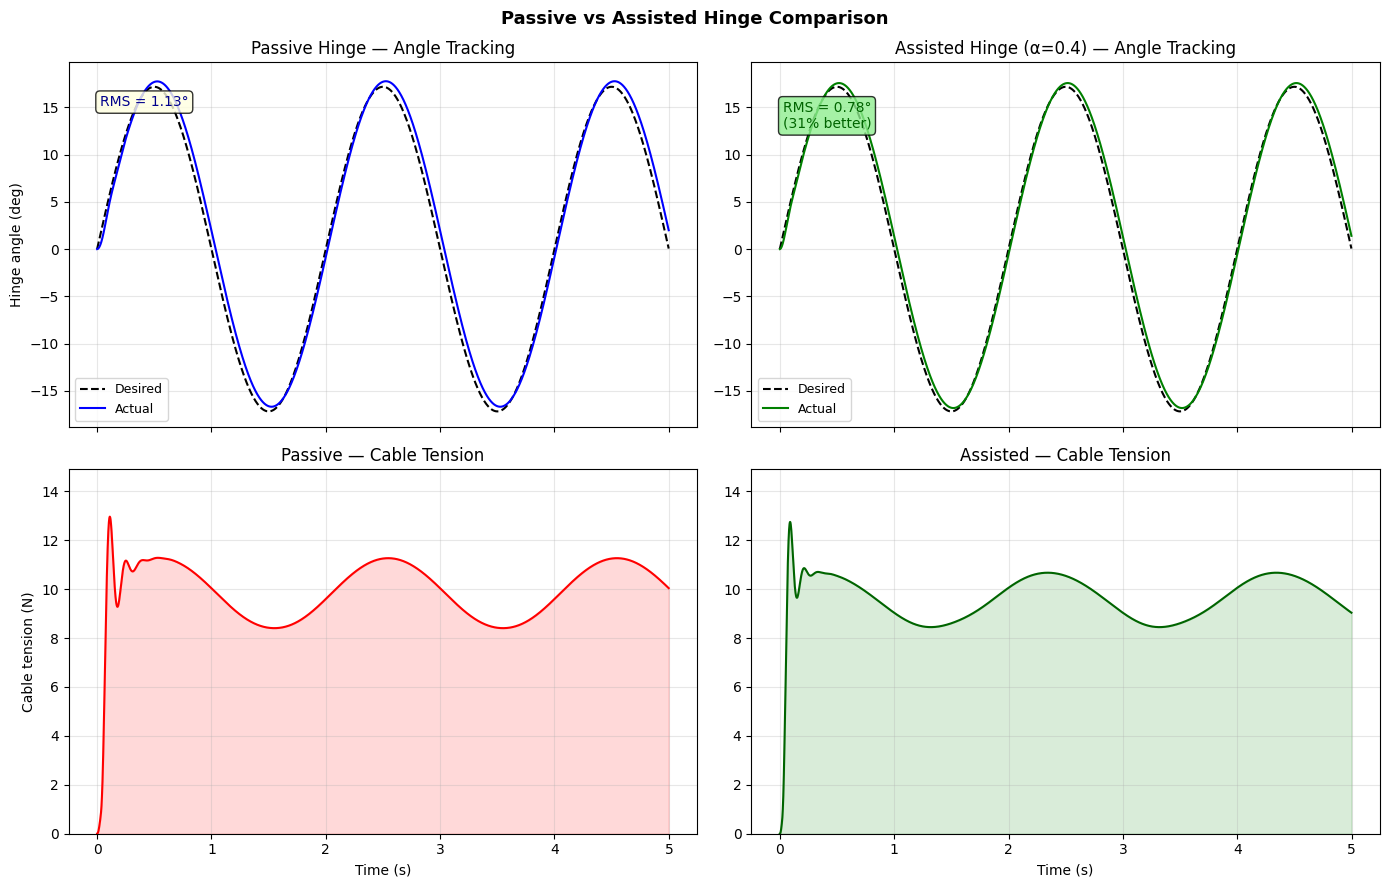

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

# Shared y-axis limits for fair comparison
angle_ylim = (min(np.degrees(q_p.min()), np.degrees(q_a.min())) - 2,
              max(np.degrees(q_p.max()), np.degrees(q_a.max())) + 2)
tension_ylim = (0, max(F_p.max(), F_a.max()) * 1.15)

# --- Top-left: Passive angle tracking ---
ax = axes[0, 0]
ax.plot(t_p, np.degrees(qd_p), 'k--', lw=1.5, label='Desired')
ax.plot(t_p, np.degrees(q_p),  'b-',  lw=1.5, label='Actual')
ax.set_ylabel('Hinge angle (deg)')
ax.set_title('Passive Hinge — Angle Tracking')
ax.set_ylim(angle_ylim)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.annotate(f'RMS = {rms_passive:.2f}°', xy=(0.05, 0.88), xycoords='axes fraction',
            fontsize=10, color='darkblue',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Top-right: Assisted angle tracking ---
ax = axes[0, 1]
ax.plot(t_a, np.degrees(qd_a), 'k--', lw=1.5, label='Desired')
ax.plot(t_a, np.degrees(q_a),  'g-',  lw=1.5, label='Actual')
ax.set_title(f'Assisted Hinge (\u03b1={ALPHA_ASSIST}) — Angle Tracking')
ax.set_ylim(angle_ylim)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.annotate(f'RMS = {rms_assisted:.2f}°\n({improvement_pct:.0f}% better)',
            xy=(0.05, 0.82), xycoords='axes fraction',
            fontsize=10, color='darkgreen',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# --- Bottom-left: Passive cable tension ---
ax = axes[1, 0]
ax.plot(t_p, F_p, 'r-', lw=1.5)
ax.fill_between(t_p, F_p, 0, alpha=0.15, color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cable tension (N)')
ax.set_title('Passive — Cable Tension')
ax.set_ylim(tension_ylim)
ax.grid(True, alpha=0.3)

# --- Bottom-right: Assisted cable tension ---
ax = axes[1, 1]
ax.plot(t_a, F_a, color='darkgreen', lw=1.5)
ax.fill_between(t_a, F_a, 0, alpha=0.15, color='green')
ax.set_xlabel('Time (s)')
ax.set_title('Assisted — Cable Tension')
ax.set_ylim(tension_ylim)
ax.grid(True, alpha=0.3)

plt.suptitle('Passive vs Assisted Hinge Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

### Key Results

| Metric | Passive | Assisted ($\alpha=0.4$) |
|--------|---------|-------------------------|
| RMS error | see output | see output |
| Peak cable tension | higher | lower |

### What We Learned

1. **Proportional hinge assist:** $\tau_{hinge} = \alpha \cdot \tau_{imp}$ distributes
   the impedance torque between the cable (indirect, spring-based) and the hinge motor
   (direct, immediate). The cable carries a fraction $(1-\alpha)$ of the required torque.
2. **Reduced cable tension:** With hinge assistance, the required cable stretch is smaller.
   This means the block position error is smaller and tracking improves.
3. **Same controller:** The outer-loop impedance law (`tau_imp = K*(qd-q) + D*(dqd-dq)`)
   is identical in both scenarios — the difference is only in `ctrl[1]`.

---

## What's Next: Notebook 8 — Resisted Hinge

In Notebook 7 the hinge assist reduced tracking error by sharing torque load with the cable.
**In Notebook 8 we reverse the hinge torque** — applying a torque that opposes the
impedance controller (simulating external resistance). We observe how tracking degrades
and compare all three scenarios (passive, assisted, resisted) side by side.